# Cape Cauldron shear lines against the GLED eddy atlas

GLED v1.0 (Liu & Abernathey 2023,
[doi:10.5194/essd-15-1765-2023](https://doi.org/10.5194/essd-15-1765-2023),
data [doi:10.5281/zenodo.7349753](https://doi.org/10.5281/zenodo.7349753))
lists coherent Lagrangian eddies found from the Lagrangian averaged vorticity
deviation (Haller et al. 2016, J. Fluid Mech. 795,
[doi:10.1017/jfm.2016.151](https://doi.org/10.1017/jfm.2016.151)) on
trajectories advected with altimetry geostrophic currents. Its windows are
30 days long and start on the first of each month.

This notebook runs the closed-shear-line search of `cape_cauldron_vortices`
on the same kind of field over the same window, 30 days forward from
2018-06-01 at 00:00, and compares what the two methods find. GLED gives each
eddy's centre and radius at the release time, the time the Cauchy-Green field
refers to. GLED advects with the 1/4 degree DUACS product, so the search runs
on the 1/8 degree product and on its 1/4 degree block mean.

The comparison runs twice per resolution. Sweep A takes its candidate centres
from the Cauchy-Green field, so it tests the whole detection chain. Sweep B
takes the GLED centres, so it tests only whether a closed shear line exists
where GLED puts an eddy.

In [1]:
# Importing Parcels pulls in the holoviews/bokeh bootstrap and prints an
# alpha-version notice, neither of which belongs on the rendered page.
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from parcels import FieldSet, Particle, ParticleSet, StatusCode
from parcels.convert import copernicusmarine_to_sgrid
from parcels.kernels import AdvectionRK4

from lcs_parcels import NeighborSeedGrid, closed_shear_lines, outermost_shear_lines

/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_14955/2240645360.py:9: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  from parcels import FieldSet, Particle, ParticleSet, StatusCode


## Currents

Daily altimetry geostrophic velocity at 1/8 degree, the local file that
`get_data` writes.

In [2]:
currents_eighth = xr.open_dataset("data/cape_cauldron_geostrophic_daily.nc").load()
currents_eighth

<xarray.Dataset> Size: 40MB
Dimensions:    (time: 34, latitude: 256, longitude: 288)
Coordinates:
  * time       (time) datetime64[ns] 272B 2018-05-31 2018-06-01 ... 2018-07-03
  * latitude   (latitude) float32 1kB -51.94 -51.81 -51.69 ... -20.19 -20.06
  * longitude  (longitude) float32 1kB -5.938 -5.812 -5.688 ... 29.81 29.94
Data variables:
    ugos       (time, latitude, longitude) float64 20MB 0.04 0.0458 ... nan nan
    vgos       (time, latitude, longitude) float64 20MB 0.0334 0.0395 ... nan
Attributes: (12/43)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    time_coverage_duration:          P1D
    time_coverage_end:               2023-12-31T12:00:00Z
    time_coverage_resolution:        P1D
    time_coverage_start:             2023-12-30T12:00:00Z
    title:                           DT merged all satellites Global Ocean Gr...
    copernicusmarine_version:        2.4.1

The 1/4 degree field is the 2 by 2 block mean of the 1/8 degree one, whose
cell centres fall on those of the 1/4 degree product. The mean skips land, so
a block that is part land takes the mean of its ocean cells.

GLED also removes the divergence that the latitude dependence of the Coriolis
parameter gives a geostrophic velocity. Neither field here has that
correction.

In [3]:
currents_quarter = currents_eighth.coarsen(
    latitude=2, longitude=2, boundary="trim"
).mean()
currents_quarter

<xarray.Dataset> Size: 10MB
Dimensions:    (time: 34, latitude: 128, longitude: 144)
Coordinates:
  * time       (time) datetime64[ns] 272B 2018-05-31 2018-06-01 ... 2018-07-03
  * latitude   (latitude) float32 512B -51.88 -51.62 -51.38 ... -20.38 -20.12
  * longitude  (longitude) float32 576B -5.875 -5.625 -5.375 ... 29.62 29.88
Data variables:
    ugos       (time, latitude, longitude) float64 5MB 0.04702 0.05183 ... nan
    vgos       (time, latitude, longitude) float64 5MB 0.03322 0.04813 ... nan
Attributes: (12/43)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    time_coverage_duration:          P1D
    time_coverage_end:               2023-12-31T12:00:00Z
    time_coverage_resolution:        P1D
    time_coverage_start:             2023-12-30T12:00:00Z
    title:                           DT merged all satellites Global Ocean Gr...
    copernicusmarine_version:        2.4.1

## Parcels v4 field sets

The product carries no depth coordinate, so the fields have no `Z` axis and
the particle sets below are released with no `z`.

In [4]:
fieldset_eighth = FieldSet.from_sgrid_conventions(
    copernicusmarine_to_sgrid(
        fields={"U": currents_eighth["ugos"], "V": currents_eighth["vgos"]}
    ),
    mesh="spherical",
)
fieldset_quarter = FieldSet.from_sgrid_conventions(
    copernicusmarine_to_sgrid(
        fields={"U": currents_quarter["ugos"], "V": currents_quarter["vgos"]}
    ),
    mesh="spherical",
)

## Seed grid and window

The GLED box at 1/25 degree for both fields, released on 2018-06-01 and read
at 30 days, the window of the `eddy_info_30d` product.

In [5]:
t0 = np.datetime64("2018-06-01")
T = np.timedelta64(30, "D")
lon_axis = np.arange(2.0, 22.0 + 1e-9, 1 / 25)
lat_axis = np.arange(-44.0, -28.0 + 1e-9, 1 / 25)
seed = NeighborSeedGrid.from_axes(lon=lon_axis, lat=lat_axis)
seed

<NeighborSeedGrid 501x401 grid, lon 2.00..22.00, lat -44.00..-28.00>

## Recovery kernel

Particles that leave the domain or hit land are turned into `NaN` in place
(Parcels would otherwise abort the run), so losses propagate as `NaN`
through every diagnostic below. The kernel sets `StatusCode.EndofLoop`
rather than `StatusCode.Delete`, because deleting shrinks the particle
array and breaks the alignment with the seed order.

In [6]:
def set_lost_to_nan(particles, fieldset):
    lost = particles.state >= StatusCode.Error
    particles.x = np.where(lost, np.nan, particles.x)
    particles.y = np.where(lost, np.nan, particles.y)
    particles.state = np.where(lost, StatusCode.EndofLoop, particles.state)

## Advect forward

In [7]:
lon, lat = seed.to_parcels_pset()

In [8]:
# 1/8 degree
pset_eighth = ParticleSet(fieldset_eighth, pclass=Particle, x=lon, y=lat, t=t0)
pset_eighth.execute(
    [AdvectionRK4, set_lost_to_nan],
    dt=np.timedelta64(1, "h"),
    runtime=T,
    verbose_progress=False,
)
forward_eighth = seed.pset_to_flowmap(
    lon=pset_eighth.x, lat=pset_eighth.y, t0=t0, t1=t0 + T
)
forward_eighth

<NeighborFlowMap 501x401 grid, lon 2.00..22.00, lat -44.00..-28.00,
                 t0 2018-06-01T00:00:00, T +30.0 days>

In [9]:
# 1/4 degree
pset_quarter = ParticleSet(fieldset_quarter, pclass=Particle, x=lon, y=lat, t=t0)
pset_quarter.execute(
    [AdvectionRK4, set_lost_to_nan],
    dt=np.timedelta64(1, "h"),
    runtime=T,
    verbose_progress=False,
)
forward_quarter = seed.pset_to_flowmap(
    lon=pset_quarter.x, lat=pset_quarter.y, t0=t0, t1=t0 + T
)
forward_quarter

<NeighborFlowMap 501x401 grid, lon 2.00..22.00, lat -44.00..-28.00,
                 t0 2018-06-01T00:00:00, T +30.0 days>

A second run over the first day at each resolution gives the rotation of the
flow. The polar rotation angle is defined modulo $2\pi$, and an eddy turns
several times in 30 days, so its sign gives the rotation sense only over a
short window.

In [10]:
one_day = np.timedelta64(1, "D")

In [11]:
# 1/8 degree
pset_day = ParticleSet(fieldset_eighth, pclass=Particle, x=lon, y=lat, t=t0)
pset_day.execute(
    [AdvectionRK4, set_lost_to_nan],
    dt=np.timedelta64(1, "h"),
    runtime=one_day,
    verbose_progress=False,
)
first_day_eighth = seed.pset_to_flowmap(
    lon=pset_day.x, lat=pset_day.y, t0=t0, t1=t0 + one_day
)

In [12]:
# 1/4 degree
pset_day = ParticleSet(fieldset_quarter, pclass=Particle, x=lon, y=lat, t=t0)
pset_day.execute(
    [AdvectionRK4, set_lost_to_nan],
    dt=np.timedelta64(1, "h"),
    runtime=one_day,
    verbose_progress=False,
)
first_day_quarter = seed.pset_to_flowmap(
    lon=pset_day.x, lat=pset_day.y, t0=t0, t1=t0 + one_day
)

Particles lost to land or to the domain edge over the 30 days, at 1/8 and at
1/4 degree.

In [13]:
(
    int(np.isnan(np.asarray(pset_eighth.x)).sum()),
    int(np.isnan(np.asarray(pset_quarter.x)).sum()),
)

(23401, 23319)

## The GLED records

`eddy_info_30d.json` and `eddy_info_90d.json` each map an eddy id to its
`date_start`, `radius` in km, polarity `cyc`, and centre position sampled
every 10 days. Index 0 of `center_lon`/`center_lat` is the position at the
start date, which is what selects an eddy into the box here.

In [14]:
def load_gled(path, *, date_start, lon_bounds, lat_bounds):
    """GLED eddies starting on `date_start` whose start position is in the box."""
    with open(path) as f:
        raw = json.load(f)
    ids, gled_lon, gled_lat, radius_km, polarity = [], [], [], [], []
    for key, start in raw["date_start"].items():
        if start != date_start:
            continue
        # GLED stores 0-360 longitudes, and this box is east of Greenwich.
        lon_0 = ((raw["center_lon"][key][0] + 180.0) % 360.0) - 180.0
        lat_0 = raw["center_lat"][key][0]
        if not (lon_bounds[0] <= lon_0 <= lon_bounds[1]):
            continue
        if not (lat_bounds[0] <= lat_0 <= lat_bounds[1]):
            continue
        ids.append(raw["id"][key])
        gled_lon.append(lon_0)
        gled_lat.append(lat_0)
        radius_km.append(raw["radius"][key])
        polarity.append(raw["cyc"][key])
    return xr.Dataset(
        {
            "lon": (
                "gled",
                np.array(gled_lon, dtype=float),
                {"long_name": "GLED eddy centre longitude", "units": "degrees_east"},
            ),
            "lat": (
                "gled",
                np.array(gled_lat, dtype=float),
                {"long_name": "GLED eddy centre latitude", "units": "degrees_north"},
            ),
            "radius_m": (
                "gled",
                np.array(radius_km, dtype=float) * 1000.0,
                {"long_name": "GLED eddy radius", "units": "m"},
            ),
            "polarity": (
                "gled",
                np.array(polarity, dtype=int),
                {
                    "long_name": "GLED eddy polarity, 1 anticyclonic and -1 cyclonic",
                    "units": "1",
                },
            ),
        },
        coords={"gled": ("gled", ids, {"long_name": "GLED eddy identifier"})},
    )

In [15]:
gled_30 = load_gled(
    "data/gled/eddyinfo/eddy_info_30d.json",
    date_start="2018-06-01",
    lon_bounds=(2.0, 22.0),
    lat_bounds=(-44.0, -28.0),
)
gled_90 = load_gled(
    "data/gled/eddyinfo/eddy_info_90d.json",
    date_start="2018-06-01",
    lon_bounds=(2.0, 22.0),
    lat_bounds=(-44.0, -28.0),
)
gled_30

<xarray.Dataset> Size: 3kB
Dimensions:   (gled: 23)
Coordinates:
  * gled      (gled) <U24 2kB '2018-06-01_030day_000047' ... '2018-06-01_030d...
Data variables:
    lon       (gled) float64 184B 15.73 13.67 8.516 14.42 ... 7.297 2.891 2.047
    lat       (gled) float64 184B -39.58 -35.3 -40.48 ... -43.17 -30.42 -38.52
    radius_m  (gled) float64 184B 7.25e+04 8.009e+04 ... 2.797e+04 3.098e+04
    polarity  (gled) int64 184B 1 -1 1 1 1 1 -1 -1 -1 1 ... 1 1 1 1 1 -1 1 -1 1

## Sweep A, the whole detection chain

`elliptic_lcs` picks candidate centres at windowed minima of
$\lambda_2 / \lambda_1$, searches them for closed shear lines, and keeps the
outermost boundary per vortex, all at the package defaults. It has only the
30-day flow map, so its boundaries carry no rotation sense.

In [16]:
eddies_a_eighth = forward_eighth.elliptic_lcs()
eddies_a_eighth

<xarray.Dataset> Size: 5MB
Dimensions:        (eddy: 11, point: 251, i: 501, j: 401)
Coordinates:
  * eddy           (eddy) int64 88B 0 1 2 3 4 5 6 7 8 9 10
    orbit_index    (eddy) int64 88B 72 147 253 124 314 111 280 88 226 222 103
  * point          (point) int64 2kB 0 1 2 3 4 5 6 ... 245 246 247 248 249 250
  * i              (i) int64 4kB 0 1 2 3 4 5 6 7 ... 494 495 496 497 498 499 500
  * j              (j) int64 3kB 0 1 2 3 4 5 6 7 ... 394 395 396 397 398 399 400
    lon_grid       (i, j) float64 2MB 2.0 2.0 2.0 2.0 ... 22.0 22.0 22.0 22.0
    lat_grid       (i, j) float64 2MB -44.0 -43.96 -43.92 ... -28.04 -28.0
    t0             datetime64[s] 8B 2018-06-01
    T              timedelta64[s] 8B 30 days
Data variables: (12/13)
    lon            (eddy, point) float64 22kB 4.443 4.443 4.444 ... nan nan nan
    lat            (eddy, point) float64 22kB -30.96 -30.94 -30.93 ... nan nan
    centre         (eddy) int64 88B 41 92 168 75 180 64 173 45 137 112 53
    centre_lon     (eddy) float64 88B 5.16 8.48 13.6 7.44 ... 11.48 10.08 5.68
    centre_lat     (eddy) float64 88B -30.96 -40.48 -35.32 ... -41.56 -38.88
    stretch        (eddy) float64 88B 1.127 0.9139 1.0 1.391 ... 1.03 1.271 1.03
    ...             ...
    area_m2        (eddy) float64 88B 1.484e+10 1.033e+10 ... 4.837e+08
    radius_m       (eddy) float64 88B 6.872e+04 5.734e+04 ... 1.241e+04
    residual_m     (eddy) float64 88B 1.676e+03 960.8 663.6 ... 247.1 1.374e+03
    centroid_lon   (eddy) float64 88B 5.234 8.479 13.58 ... 11.48 10.2 5.807
    centroid_lat   (eddy) float64 88B -30.99 -40.53 -35.23 ... -41.5 -38.78
    cg_anisotropy  (i, j) float64 2MB nan nan nan nan nan ... nan nan nan nan
Attributes: (12/20)
    stretch_min:               0.6770568744981647
    stretch_max:               1.4769807938826427
    n_stretch:                 27
    max_radius_m:              150000.0
    launch_spacing_m:          3598.343413748942
    step_m:                    1799.171706874471
    ...                        ...
    centres_edge_cells_j:      12
    centres_window_m:          100000.0
    centres_window_cells_i:    27
    centres_window_cells_j:    21
    centres_grid_spacing_i_m:  3598.343413748942
    centres_grid_spacing_j_m:  4447.797065782255

In [17]:
eddies_a_quarter = forward_quarter.elliptic_lcs()
eddies_a_quarter

<xarray.Dataset> Size: 5MB
Dimensions:        (eddy: 11, point: 248, i: 501, j: 401)
Coordinates:
  * eddy           (eddy) int64 88B 0 1 2 3 4 5 6 7 8 9 10
    orbit_index    (eddy) int64 88B 67 185 346 246 210 290 101 92 97 0 197
  * point          (point) int64 2kB 0 1 2 3 4 5 6 ... 242 243 244 245 246 247
  * i              (i) int64 4kB 0 1 2 3 4 5 6 7 ... 494 495 496 497 498 499 500
  * j              (j) int64 3kB 0 1 2 3 4 5 6 7 ... 394 395 396 397 398 399 400
    lon_grid       (i, j) float64 2MB 2.0 2.0 2.0 2.0 ... 22.0 22.0 22.0 22.0
    lat_grid       (i, j) float64 2MB -44.0 -43.96 -43.92 ... -28.04 -28.0
    t0             datetime64[s] 8B 2018-06-01
    T              timedelta64[s] 8B 30 days
Data variables: (12/13)
    lon            (eddy, point) float64 22kB 4.443 4.443 4.444 ... nan nan nan
    lat            (eddy, point) float64 22kB -30.96 -30.94 -30.93 ... nan nan
    centre         (eddy) int64 88B 42 96 211 178 145 196 80 46 68 21 124
    centre_lon     (eddy) float64 88B 5.16 8.44 15.52 13.56 ... 6.8 3.8 10.2
    centre_lat     (eddy) float64 88B -30.96 -40.48 -39.48 ... -41.72 -41.44
    stretch        (eddy) float64 88B 1.162 0.9704 1.03 ... 1.03 1.477 1.197
    ...             ...
    area_m2        (eddy) float64 88B 1.466e+10 9.541e+09 ... 8.387e+08
    radius_m       (eddy) float64 88B 6.832e+04 5.511e+04 ... 2.13e+04 1.634e+04
    residual_m     (eddy) float64 88B 1.579e+03 1.453e+03 ... 974.5 1.733e+03
    centroid_lon   (eddy) float64 88B 5.227 8.477 15.63 ... 6.688 3.964 10.15
    centroid_lat   (eddy) float64 88B -31.0 -40.53 -39.59 ... -41.75 -41.49
    cg_anisotropy  (i, j) float64 2MB nan nan nan nan nan ... nan nan nan nan
Attributes: (12/20)
    stretch_min:               0.6770568744981647
    stretch_max:               1.4769807938826427
    n_stretch:                 27
    max_radius_m:              150000.0
    launch_spacing_m:          3598.343413748942
    step_m:                    1799.171706874471
    ...                        ...
    centres_edge_cells_j:      12
    centres_window_m:          100000.0
    centres_window_cells_i:    27
    centres_window_cells_j:    21
    centres_grid_spacing_i_m:  3598.343413748942
    centres_grid_spacing_j_m:  4447.797065782255

## Sweep B, from the GLED centres

The same search launched from the GLED 30-day eddy centres. A centre GLED
found cannot be missed here, so this separates centre selection from the
existence of a closed shear line. The boundaries take their rotation sense
from the first day.

In [18]:
eddies_b_eighth = outermost_shear_lines(
    closed_shear_lines(
        forward_eighth, centre_lon=gled_30["lon"], centre_lat=gled_30["lat"]
    ),
    rotation=first_day_eighth.polar_rotation(),
)
eddies_b_quarter = outermost_shear_lines(
    closed_shear_lines(
        forward_quarter, centre_lon=gled_30["lon"], centre_lat=gled_30["lat"]
    ),
    rotation=first_day_quarter.polar_rotation(),
)
eddies_b_quarter

<xarray.Dataset> Size: 37kB
Dimensions:         (eddy: 9, point: 240)
Coordinates:
  * eddy            (eddy) int64 72B 0 1 2 3 4 5 6 7 8
    orbit_index     (eddy) int64 72B 284 157 10 72 171 208 301 306 302
  * point           (point) int64 2kB 0 1 2 3 4 5 6 ... 234 235 236 237 238 239
Data variables: (12/13)
    lon             (eddy, point) float64 17kB 4.467 4.467 4.469 ... nan nan nan
    lat             (eddy, point) float64 17kB -30.95 -30.94 -30.92 ... nan nan
    centre          (eddy) int64 72B 9 2 0 1 6 7 12 18 13
    centre_lon      (eddy) float64 72B 5.297 8.516 15.73 ... 5.484 8.141 10.33
    centre_lat      (eddy) float64 72B -30.95 -40.48 -39.58 ... -28.27 -41.52
    stretch         (eddy) float64 72B 1.094 0.9704 1.03 ... 1.062 1.234 1.162
    ...              ...
    area_m2         (eddy) float64 72B 1.37e+10 9.788e+09 ... 2.15e+09 7.115e+08
    radius_m        (eddy) float64 72B 6.604e+04 5.582e+04 ... 1.505e+04
    residual_m      (eddy) float64 72B 1.787e+03 1.298e+03 ... 1.596e+03
    centroid_lon    (eddy) float64 72B 5.226 8.477 15.61 ... 5.331 8.317 10.14
    centroid_lat    (eddy) float64 72B -30.99 -40.53 -39.59 ... -28.31 -41.51
    rotation_sense  (eddy) int64 72B 1 1 1 -1 -1 -1 -1 1 -1
Attributes:
    stretch_min:            0.6770568744981647
    stretch_max:            1.4769807938826427
    n_stretch:              27
    max_radius_m:           150000.0
    launch_spacing_m:       3598.343413748942
    step_m:                 1799.171706874471
    closure_tol_m:          1799.171706874471
    n_centres:              23
    n_never_returned:       2078
    n_orbits_in:            307
    n_centres_with_orbits:  9

## Matching

A GLED eddy is matched when the centroid of a boundary lies within its
radius. In the southern hemisphere a counter-clockwise eddy is anticyclonic,
so `rotation_sense` is GLED's polarity there.

In [19]:
def distance_m(*, lon_a, lat_a, lon_b, lat_b):
    lat_mid = np.deg2rad(0.5 * (lat_a + lat_b))
    dx = 6_371_000.0 * np.cos(lat_mid) * np.deg2rad(lon_b - lon_a)
    dy = 6_371_000.0 * np.deg2rad(lat_b - lat_a)
    return np.hypot(dx, dy)


def match_to_gled(eddies, *, gled):
    """One row per GLED eddy with the nearest boundary, distances and radii in km."""
    distance = distance_m(
        lon_a=gled["lon"],
        lat_a=gled["lat"],
        lon_b=eddies["centroid_lon"],
        lat_b=eddies["centroid_lat"],
    )
    nearest = eddies.isel(eddy=distance.argmin("eddy"))
    return pd.DataFrame(
        {
            "gled_lon": gled["lon"].values,
            "gled_lat": gled["lat"].values,
            "gled_radius_km": gled["radius_m"].values / 1000,
            "distance_km": distance.min("eddy").values / 1000,
            "radius_km": nearest["radius_m"].values / 1000,
            "stretch": nearest["stretch"].values,
            "matched": (distance.min("eddy") <= gled["radius_m"]).values,
            "same_polarity": (
                (nearest["rotation_sense"] == gled["polarity"]).values
                if "rotation_sense" in nearest
                else np.nan
            ),
        },
        index=gled["gled"].values,
    )

Each GLED eddy against the nearest sweep-A boundary at 1/4 degree.

In [20]:
match_to_gled(eddies_a_quarter, gled=gled_30).round(2)

,gled_lon,gled_lat,gled_radius_km,distance_km,radius_km,stretch,matched,same_polarity
2018-06-01_030day_000047,15.73,-39.58,72.50,8.65,52.11,1.03,True,NaN
2018-06-01_030day_000055,13.67,-35.30,80.09,10.10,45.09,0.97,True,NaN
2018-06-01_030day_000057,8.52,-40.48,73.27,5.98,55.11,0.97,True,NaN
2018-06-01_030day_000116,14.42,-41.05,65.07,192.27,52.11,1.03,False,NaN
2018-06-01_030day_000122,13.27,-41.39,65.07,260.35,16.34,1.20,False,NaN
2018-06-01_030day_000123,13.89,-42.11,64.55,316.65,52.11,1.03,False,NaN
2018-06-01_030day_000125,11.39,-32.86,86.62,18.83,42.92,1.06,True,NaN
2018-06-01_030day_000150,14.52,-31.61,58.92,2.01,36.54,0.94,True,NaN
2018-06-01_030day_000163,20.80,-41.17,31.84,471.58,52.11,1.03,False,NaN
2018-06-01_030day_000187,5.30,-30.95,100.40,8.37,68.32,1.16,True,NaN


The same at 1/8 degree.

In [21]:
match_to_gled(eddies_a_eighth, gled=gled_30).round(2)

,gled_lon,gled_lat,gled_radius_km,distance_km,radius_km,stretch,matched,same_polarity
2018-06-01_030day_000047,15.73,-39.58,72.50,514.01,14.93,1.27,False,NaN
2018-06-01_030day_000055,13.67,-35.30,80.09,11.29,43.15,1.00,True,NaN
2018-06-01_030day_000057,8.52,-40.48,73.27,5.67,57.34,0.91,True,NaN
2018-06-01_030day_000116,14.42,-41.05,65.07,356.08,14.93,1.27,False,NaN
2018-06-01_030day_000122,13.27,-41.39,65.07,255.45,14.93,1.27,False,NaN
2018-06-01_030day_000123,13.89,-42.11,64.55,312.85,14.93,1.27,False,NaN
2018-06-01_030day_000125,11.39,-32.86,86.62,13.71,18.87,1.03,True,NaN
2018-06-01_030day_000150,14.52,-31.61,58.92,1.99,33.55,0.91,True,NaN
2018-06-01_030day_000163,20.80,-41.17,31.84,885.11,14.93,1.27,False,NaN
2018-06-01_030day_000187,5.30,-30.95,100.40,7.49,68.72,1.13,True,NaN


## The two resolutions side by side

The radius ratio is the boundary's equivalent radius over the GLED radius. The
polarity agreement is over the matched GLED eddies, for sweep B, whose
boundaries carry a rotation sense.

In [22]:
def summary(eddies, *, gled):
    rows = match_to_gled(eddies, gled=gled)
    matched = rows[rows["matched"]]
    distance = distance_m(
        lon_a=gled["lon"],
        lat_a=gled["lat"],
        lon_b=eddies["centroid_lon"],
        lat_b=eddies["centroid_lat"],
    )
    return {
        "boundaries": eddies.sizes["eddy"],
        "boundaries inside a GLED eddy": int(
            (distance <= gled["radius_m"]).any("gled").sum()
        ),
        "GLED eddies matched": len(matched),
        "radius ratio, median": float(
            (matched["radius_km"] / matched["gled_radius_km"]).median()
        ),
        "same polarity": matched["same_polarity"].sum(min_count=1),
    }

In [23]:
pd.DataFrame(
    {
        "A, 1/8 degree": summary(eddies_a_eighth, gled=gled_30),
        "A, 1/4 degree": summary(eddies_a_quarter, gled=gled_30),
        "B, 1/8 degree": summary(eddies_b_eighth, gled=gled_30),
        "B, 1/4 degree": summary(eddies_b_quarter, gled=gled_30),
    }
).round(3)

,"A, 1/8 degree","A, 1/4 degree","B, 1/8 degree","B, 1/4 degree"
boundaries,11.000,11.000,9.000,9.000
boundaries inside a GLED eddy,7.000,8.000,9.000,9.000
GLED eddies matched,7.000,8.000,9.000,9.000
"radius ratio, median",0.539,0.592,0.551,0.555
same polarity,NaN,NaN,9.000,9.000


## GLED and the closed shear lines

The GLED eddies as circles at their radius, blue for cyclonic and red for
anticyclonic, with a thick outline where the 90-day product carries the eddy
too. A 90-day eddy is coherent over three times the window here, so its
outline marks persistence and not a 30-day boundary. The boundaries of sweep A
are drawn solid and those of sweep B dashed, over the decimal logarithm of the
eigenvalue ratio the sweep-A centres were picked from, its colour range clipped
to the 2nd to 98th percentile so the grid-scale speckle does not set it.

In [24]:
def plot_against_gled(eddies_a, eddies_b):
    angle = np.linspace(0.0, 2 * np.pi, 200)
    _, ax = plt.subplots(figsize=(11, 8))
    np.log10(eddies_a["cg_anisotropy"]).assign_attrs(
        long_name="log10 of the Cauchy-Green eigenvalue ratio lambda_2 / lambda_1",
        units="1",
    ).plot.pcolormesh(x="lon_grid", y="lat_grid", ax=ax, cmap="Greys", robust=True)
    for records, width in ((gled_30, 1.2), (gled_90, 3.0)):
        for e in range(records.sizes["gled"]):
            eddy = records.isel(gled=e)
            radius_deg = float(eddy["radius_m"]) / 111_195.0
            ax.plot(
                float(eddy["lon"])
                + radius_deg * np.cos(angle) / np.cos(np.deg2rad(float(eddy["lat"]))),
                float(eddy["lat"]) + radius_deg * np.sin(angle),
                color="tab:red" if int(eddy["polarity"]) > 0 else "tab:blue",
                lw=width,
            )
    ax.plot(eddies_a["lon"].T, eddies_a["lat"].T, color="tab:green", lw=2.0)
    ax.plot(eddies_b["lon"].T, eddies_b["lat"].T, color="tab:green", lw=2.0, ls="--")
    plt.show()

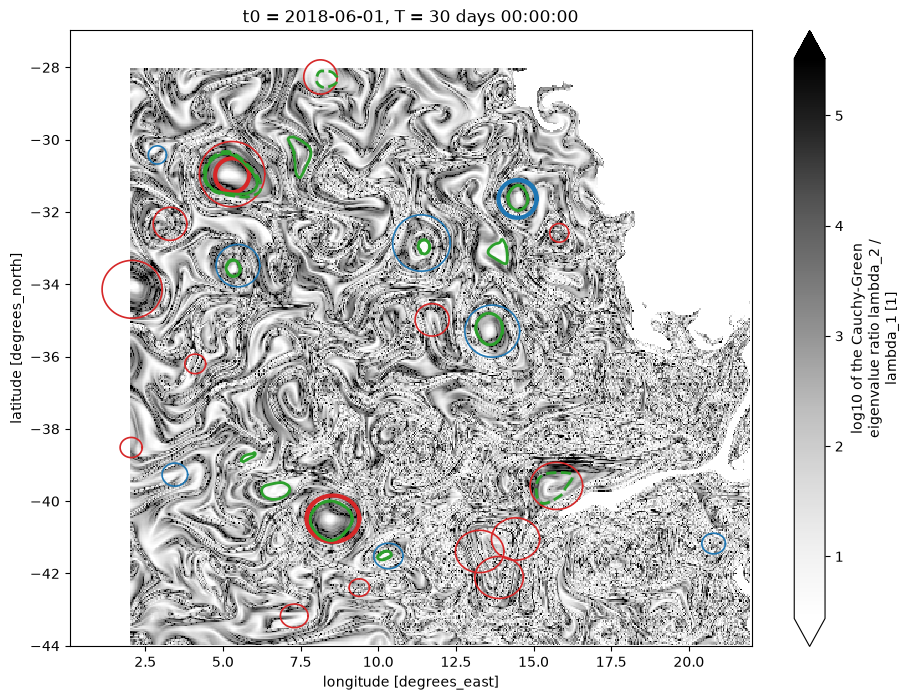

In [25]:
# 1/8 degree
plot_against_gled(eddies_a_eighth, eddies_b_eighth)

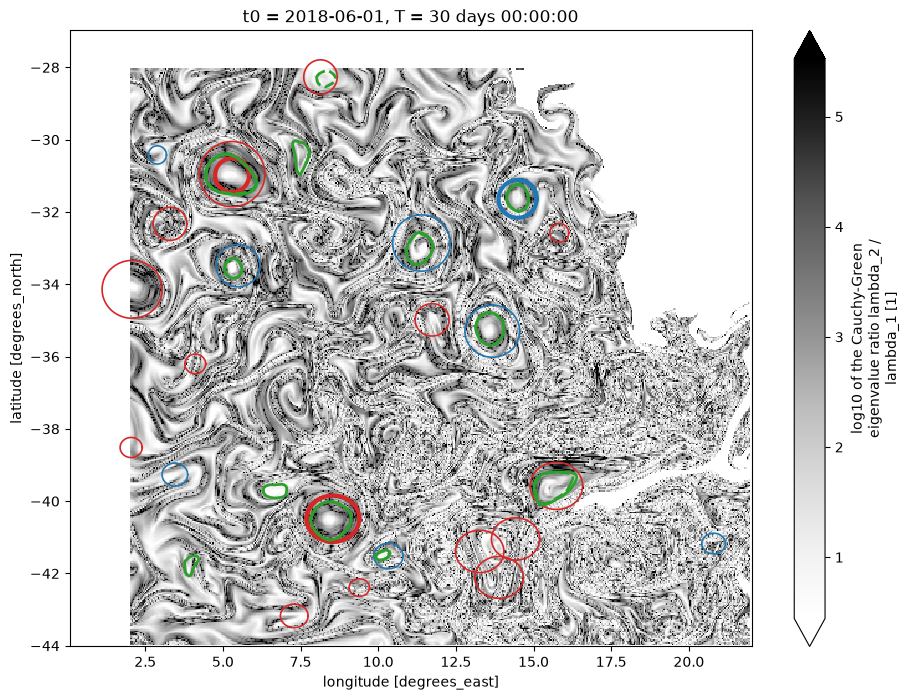

In [26]:
# 1/4 degree
plot_against_gled(eddies_a_quarter, eddies_b_quarter)

## Outcome

The 30-day GLED product places 23 eddies in the box on 1 June 2018. Advection
lost 23401 of the 200901 particles at 1/8 degree and 23319 at 1/4 degree.

Sweep A returns 11 boundaries at each resolution. At 1/8 degree 7 of them lie
inside a GLED eddy and 7 GLED eddies are matched. At 1/4 degree it is 8 and 8.
Sweep B, from the GLED centres, returns 9 boundaries at each resolution, all
inside a GLED eddy, so 9 of the 23 GLED eddies have a closed shear line at
their centre. Over the first day every one of those 9 turns in the sense
GLED's polarity gives, at both resolutions.

The median boundary radius over the GLED radius is 0.539 and 0.592 for
sweep A at 1/8 and 1/4 degree, and 0.551 and 0.555 for sweep B.